# Week2 복습과제 — 7. 트랜스포머 (Transformer)

- 교재: 『(파이토치 트랜스포머를 활용한) 자연어 처리와 컴퓨터 비전 심층학습』
- 범위: 7장 트랜스포머 – Transformer 절 (p.357 ~ 387)
- 실습: 위치 인코딩 구현, 파이토치 `nn.Transformer` 기반 독일어 → 영어 번역 모델(Multi30k) 학습·추론
- 작성자: 유다연

| 순서 | 내용 | 교재 |
|---|---|---|
| 0 | 실행 환경 설정 | p.369 |
| 1 | 트랜스포머 개요 | p.357 ~ 359 |
| 2 | 입력 임베딩과 위치 인코딩 — 예제 7.1 | p.359 ~ 361 |
| 3 | 특수 토큰과 입력 임베딩 | p.362 ~ 363 |
| 4 | 트랜스포머 인코더·디코더 | p.364 ~ 368 |
| 5 | 모델 실습 — 예제 7.2 ~ 7.8 | p.368 ~ 387 |
| 6 | 정리 (실행 결과·교재 대비 수정 사항·코드 리뷰 메모) | – |

## 0. 실행 환경 설정

- 교재 설치 명령: `pip install torchdata torchtext portalocker`
- 버전 고정 이유
  - torchtext: 0.18.0이 최종 릴리스(개발 중단), torch 2.3.0 기준 빌드 → 최신 torch에서 import 오류
  - torchdata: 0.7.x는 torch 2.3.0과 import 충돌(`DILL_AVAILABLE` 제거) → 0.8.0 사용
  - numpy: torch 2.3.0이 NumPy 1.x 기준 빌드 → `numpy<2` 고정 (`.numpy()` 변환 오류 방지)
- Colab 실행 시: 설치 셀 실행 후 **런타임 재시작** 필요
- Python 3.8 ~ 3.12 환경 필요 (torch 2.3.0·torchtext 0.18.0 휠 지원 범위, 본 실행: Python 3.11)
- spaCy 토크나이저 모델: 독일어 `de_core_news_sm`, 영어 `en_core_web_sm` (교재 각주 3)
- 본 노트북 실행 환경
  - CPU 실행(GPU 없음) → `DEVICE = "cpu"`, 교재 출력의 `device='cuda:0'` 표기 없음
  - spaCy 공식 모델 다운로드가 제한된 환경 → `spacy.blank("de")`, `spacy.blank("en")` 기반 토크나이저 전용 패키지를 같은 이름으로 설치해 실행 (아래 버전 `0.0.0` 표기)
  - torchtext `get_tokenizer("spacy")`는 spaCy 파이프라인 중 토크나이저만 사용 → 토큰화 결과 동일 (예제 7.5 배치 텐서 값이 교재 출력과 일치)

In [1]:
# 교재 원본: pip install torchdata torchtext portalocker
# [수정] torchtext 최종 버전(0.18.0)과 호환되는 조합으로 버전 고정
%pip install -q torch==2.3.0 torchtext==0.18.0 torchdata==0.8.0 portalocker "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# spaCy 사전 학습 토크나이저 모델 설치 (교재 각주 3: python -m spacy download ...)
import importlib.util
from importlib.metadata import version

for model_name in ["de_core_news_sm", "en_core_web_sm"]:
    if importlib.util.find_spec(model_name) is None:  # 미설치 시에만 다운로드
        !python -m spacy download {model_name}
    print(model_name, version(model_name))

de_core_news_sm 0.0.0
en_core_web_sm 0.0.0


In [3]:
import warnings
import torch
import torchtext
import torchdata
import spacy

# 라이브러리 지원 중단 안내 경고 메시지 비활성화 (실행 결과에는 영향 없음)
torchtext.disable_torchtext_deprecation_warning()  # torchtext 개발 중단 경고
warnings.filterwarnings("ignore", message=r"(?s).*'datapipes', 'dataloader2' modules are deprecated")  # torchdata 경고

print("torch     :", torch.__version__)
print("torchtext :", torchtext.__version__)
print("torchdata :", torchdata.__version__)
print("spacy     :", spacy.__version__)
print("CUDA 사용 가능 여부:", torch.cuda.is_available())

torch     : 2.3.0+cu121
torchtext : 0.18.0+cpu
torchdata : 0.8.0+cpu
spacy     : 3.8.16
CUDA 사용 가능 여부: False


## 1. 트랜스포머 개요 (p.357 ~ 359)

- 트랜스포머(Transformer): 순환 신경망·합성곱 신경망 없이 **어텐션 메커니즘(Attention Mechanism)만으로** 시퀀스 임베딩을 표현하는 모델
- 활용 분야: 기계 번역, 챗봇, 음성 인식 등 자연어 처리 전반
- 인코더: 입력 시퀀스를 임베딩해 고차원 벡터로 변환
- 디코더: 인코더 출력을 입력으로 받아 출력 시퀀스 생성
- 어텐션: 인코더–디코더 단어 사이 상관관계 계산 → 중요한 정보에 집중 → 입력 단어가 출력의 어떤 단어와 관련되는지 파악
- 장점
  - 병렬 처리 가능 → 순환 신경망 기반 모델 대비 빠른 학습, 대규모 데이터세트에서 높은 성능
  - 문장 전체 정보를 한 번에 고려 → 문장이 길어져도 성능 유지
- 구조(그림 7.2): 인코더·디코더 각각 N개의 **트랜스포머 블록(Transformer Block)** = 멀티 헤드 어텐션 + 순방향 신경망 (+ 덧셈 & 정규화)
  - 멀티 헤드 어텐션: 입력 시퀀스에서 쿼리(Query)·키(Key)·값(Value) 벡터를 만들어 **셀프 어텐션(Self-Attention)** 수행 → 쿼리–키 유사도를 가중치로 값 벡터 합산
  - 순방향 신경망: 어텐션으로 갱신된 임베딩을 선형 계층 + 활성화 함수로 고도화
- 소스(Source)·타깃(Target): 참조 언어 = 소스, 생성 언어 = 타깃 (예: 영어 → 한국어 번역 시 영어 = 소스, 한국어 = 타깃)
- 인코더 → 위치 인코딩된 소스 임베딩으로 트랜스포머 블록 출력 벡터 생성 / 디코더 → **마스크 멀티 헤드 어텐션(Masked Multi-Head Attention)**으로 타깃 시퀀스 순차 생성, 인코더 출력 참조
- 참고: 트랜스포머 기반 파생 모델(표 7.1)

| 모델 | 학습 구조 | 학습 방법 | 학습 방향성 |
|---|---|---|---|
| BERT | 인코더 | 오토 인코딩 | 양방향 |
| GPT | 디코더 | 자기 회귀 | 단방향 |
| BART | 인코더 + 디코더 | 오토 인코딩 + 자기 회귀 | 양방향 + 단방향 |
| ELECTRA | 인코더 + 판별기 | 오토 인코딩 + 대체 토큰 탐지 | 양방향 |
| T5 | 인코더 + 디코더 | 오토 인코딩 + 자기 회귀 + 다양한 자연어 처리 작업 학습 | 양방향 |

## 2. 입력 임베딩과 위치 인코딩 (p.359 ~ 361)

- 트랜스포머는 입력 시퀀스를 병렬 구조로 처리 → 단어의 **순서 정보 부재**
- 위치 인코딩(Positional Encoding): 각 위치를 나타내는 벡터를 입력 임베딩에 **더해** 순서 정보 반영
- 계산 방식(수식 7.1): 토큰 위치를 각도로 표현해 sin·cos 함수로 벡터 생성

$$PE_{(pos,\ 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad PE_{(pos,\ 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- $pos$: 시퀀스 내 단어 위치, $i$: 임베딩 차원 인덱스 → 짝수 차원은 sin, 홀수 차원은 cos
- $1/10000^{2i/d_{model}}$: 차원마다 주기를 다르게 만드는 스케일링 인자 → 위치별 고유한 주기 신호 생성

### 예제 7.1 위치 인코딩

- `div_term`: $\exp\left(2i \cdot \frac{-\ln 10000}{d_{model}}\right) = \frac{1}{10000^{2i/d_{model}}}$ → 거듭제곱 대신 로그 공간에서 계산
- `pe` 텐서: `[최대 시퀀스, 1, 입력 임베딩 차원]` = `[50, 1, 128]` (가운데 1 = 배치 차원 브로드캐스팅용)
- `register_buffer`: 학습 중 갱신되지 않는 텐서로 등록 (단, `state_dict` 저장·`.to(device)` 이동 대상에는 포함)
- `forward`: 입력 임베딩 + 위치 인코딩 → 드롭아웃

pe shape: torch.Size([50, 1, 128])


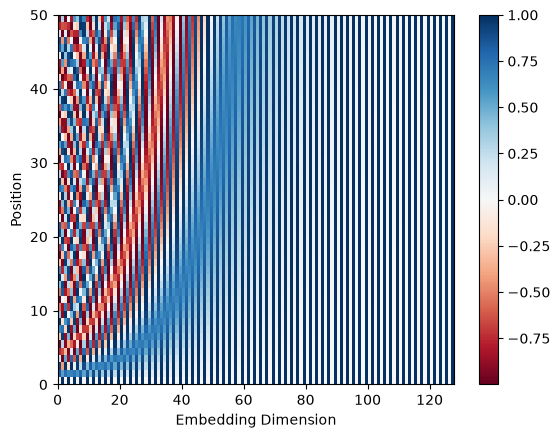

In [4]:
import math
import torch
from torch import nn
from matplotlib import pyplot as plt


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # 위치 인덱스 pos: [max_len, 1]
        position = torch.arange(max_len).unsqueeze(1)
        # 짝수 차원 인덱스(2i)별 1 / 10000^(2i/d_model): [d_model / 2]
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        # 위치 인코딩 텐서: [max_len, 1, d_model]
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)  # 짝수 차원(2i): sin
        pe[:, 0, 1::2] = torch.cos(position * div_term)  # 홀수 차원(2i+1): cos
        # 학습 대상이 아닌 고정값 → 매개변수 대신 버퍼로 등록
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [시퀀스 길이, 배치 크기, d_model] → 시퀀스 길이만큼 위치 인코딩 덧셈
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


# 입력 임베딩 차원 128, 최대 시퀀스 50의 위치 인코딩 생성
encoding = PositionalEncoding(d_model=128, max_len=50)
print("pe shape:", encoding.pe.shape)  # [확인] [최대 시퀀스, 1, 입력 임베딩 차원]

# 위치(세로축) × 임베딩 차원(가로축)별 위치 인코딩 값 시각화
plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

- 결과 해석
  - 앞쪽 차원(작은 $i$): 주기가 짧아 위치에 따라 값이 빠르게 변하는 줄무늬
  - 뒤쪽 차원(큰 $i$): 주기가 길어 거의 일정한 값 (sin ≈ 0, cos ≈ 1)
  - 위치마다 차원별 값 조합이 모두 다름 → 모델이 토큰 순서를 구분하는 근거

## 3. 특수 토큰과 입력 임베딩 (p.362 ~ 363)

- 단어 토큰 외에 문장 시작·끝 표시, 마스킹 영역 등에 **특수 토큰** 사용

| 토큰 | 의미 | 역할 |
|---|---|---|
| `<bos>` | Beginning of Sentence | 문장 시작 표시 |
| `<eos>` | End of Sentence | 문장 종료 표시 |
| `<unk>` | Unknown | 어휘 사전에 없는 단어(모르는 단어) 대체 |
| `<pad>` | Padding | 문장 길이를 일정하게 맞추기 위한 빈 공간 채움 |

- 예시(그림 7.3): "ChatGPT는 트랜스포머 모델로 이뤄져 있다" → `<bos>` · ChatGPT · 는 · 트랜스포머 · 모델 · 로 · `<unk>` · 있다 · `<eos>` · `<pad>`
- 마스킹 활용: 번역 모델 디코더에서 현재 위치 이후 토큰을 마스크 → 이전 토큰만 참조
- 입력 임베딩(그림 7.4): 원-핫 벡터 × 임베딩 행렬 (Word2Vec과 동일한 방식)
  - 토큰 1개: `[1, V] × [V, d] → [1, d]` (V: 어휘 사전 크기, d: 입력 임베딩 차원)
  - 문장 N개(최대 길이 S): `[N, S, V] → [N, S, d]`
  - 생성된 임베딩 텐서는 트랜스포머 모든 계층의 입력으로 사용
  - 실제 구현(`nn.Embedding`): 원-핫 곱셈 대신 인덱스로 임베딩 행렬의 행을 조회 → 결과 동일, 연산 효율적

## 4. 트랜스포머 인코더와 디코더 (p.364 ~ 368)

### 4.1 트랜스포머 인코더 (그림 7.5)

- 입력: 위치 인코딩이 적용된 소스 입력 임베딩 `[N, S, d]`
- 선형 변환으로 3개의 벡터 생성
  - 쿼리 벡터 $v^q$: 현재 시점에서 질문이 되는 벡터, 다른 시점 정보를 참조하는 기준
  - 키 벡터 $v^k$: 쿼리와 비교되는 대상 벡터
  - 값 벡터 $v^v$: 어텐션 스코어를 얼마나 반영할지 정하는 가중합 대상 벡터
- 어텐션 스코어(수식 7.2): 쿼리·키 내적 → `[N, S, S]` 스코어 맵

$$\text{score}(v^q, v^k) = \text{softmax}\left(\frac{(v^q)^T \cdot v^k}{\sqrt{d}}\right)$$

- $\sqrt{d}$로 나누는 이유: 벡터 차원이 커질수록 내적 값도 커지는 문제 완화
- 스코어(확률) × 값 벡터 → 셀프 어텐션된 벡터
- 멀티 헤드(Multi-Head): `[N, S, d]` → `[N, k, S, d/k]`로 나눠 k개 헤드가 독립적으로 셀프 어텐션 → 임베딩 차원 축으로 병합(concatenation) → `[N, S, d]`
- 덧셈 & 정규화: 어텐션 이전 입력 + 이후 출력 (잔차 연결) → 기울기 소실 완화 → 임베딩 차원 축 계층 정규화(Layer Normalization)
- 순방향 신경망: 선형 임베딩 + ReLU 또는 1차원 합성곱 → 다시 덧셈 & 정규화
- 인코더 블록 여러 개를 쌓아 입력 정보 점차 추상화 → 마지막 블록 출력이 디코더 멀티 헤드 어텐션의 **키·값**으로 사용

### 4.2 트랜스포머 디코더 (그림 7.6)

- 입력: 위치 인코딩이 적용된 타깃 입력 임베딩
- 마스크 멀티 헤드 어텐션: **인과성(Causality)** 반영
  - 첫 번째 쿼리 → 첫 번째 키만, 두 번째 쿼리 → 첫 번째·두 번째 키만 참조
  - 마스크 영역에 −inf를 더함 → 소프트맥스 후 가중치 0 → 현재 위치 이후 토큰 정보 차단
- 인코더–디코더 멀티 헤드 어텐션: 쿼리 = 타깃(디코더), 키·값 = 소스(인코더 출력)
- 마지막 디코더 블록 출력 `[N, S, d]` → 선형 변환 + 소프트맥스 → 타깃 시퀀스 위치별 예측 확률
- 추론: 토큰을 순차적으로 생성, 아직 생성되지 않은 위치는 `<pad>`로 채움 (표 7.2)

| 추론 순서 | 디코더 입력 | 디코더 출력 |
|---|---|---|
| 1 | [BOS], [PAD], [PAD], … | [BOS], 'ChatGPT', [PAD], … |
| 2 | [BOS], 'ChatGPT', [PAD], … | [BOS], 'ChatGPT', '는', [PAD], … |
| … | … | … |
| 7 | [BOS], 'ChatGPT', '는', '트랜스포머', '모델로', '이뤄져', '있다', [PAD], [PAD] | [BOS], 'ChatGPT', '는', '트랜스포머', '모델로', '이뤄져', '있다', [EOS], [PAD] |

## 5. 모델 실습 — 독일어 → 영어 번역 (p.368 ~ 387)

- 데이터: **Multi30k** — 영어–독일어 병렬 말뭉치(Parallel corpus), 약 30,000쌍 (train 29,000 / valid 1,014)
- 라이브러리
  - torchdata: 대규모 데이터세트 로드·변환·배치 API
  - torchtext: 텍스트 전처리·데이터세트 관리 도구
  - portalocker: 파일 락 관리 → Multi30k 다운로드·압축 해제 과정에서 내부 사용
- 흐름: 토큰화·어휘 사전(7.2) → 모델 정의(7.3·7.4) → 배치 생성(7.5) → 마스크 생성(7.6) → 학습·평가(7.7) → 번역(7.8)
- 코드 기준 소스 = 독일어(`de`), 타깃 = 영어(`en`)

### 5.1 예제 7.2 데이터세트 다운로드 및 전처리 (p.369 ~ 371)

- `get_tokenizer("spacy", language=...)`: spaCy 사전 학습 모델의 토크나이저 로드 → `token_transform`
- `build_vocab_from_iterator`: 토큰 이터레이터로 어휘 사전(토큰 → 인덱스) 생성 → `vocab_transform`
  - `min_freq=1`: 최소 등장 빈도 (1회 이상 등장한 토큰 모두 포함)
  - `specials` + `special_first=True`: 특수 토큰을 사전 맨 앞에 배치 → `<unk>`=0, `<pad>`=1, `<bos>`=2, `<eos>`=3
- `set_default_index(UNK_IDX)`: 사전에 없는 토큰 조회 시 `<unk>` 인덱스 반환
- 교재 안내: 주피터 노트북에서 `AttributeError: 'NoneType' object has no attribute 'Lock'` 발생 시 커널 재시작

In [5]:
from torchtext.datasets import Multi30k
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


def generate_tokens(text_iter, language):
    # 데이터 샘플 = (독일어 문장, 영어 문장) → 언어별 튜플 위치
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

    for text in text_iter:
        # 해당 언어 문장을 토큰화한 리스트를 하나씩 반환 (제너레이터)
        yield token_transform[language](text[language_index[language]])


SRC_LANGUAGE = "de"  # 소스 언어: 독일어
TGT_LANGUAGE = "en"  # 타깃 언어: 영어
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3  # 특수 토큰 인덱스
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

# 언어별 spaCy 토크나이저 (문장 → 토큰 리스트)
token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
}
print("Token Transform:")
print(token_transform)

# 언어별 어휘 사전 (토큰 → 인덱스)
vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    # 학습 데이터 (독일어, 영어) 튜플 이터레이터
    train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    vocab_transform[language] = build_vocab_from_iterator(
        generate_tokens(train_iter, language),
        min_freq=1,                # 1회 이상 등장한 토큰 모두 포함
        specials=special_symbols,  # 특수 토큰 추가
        special_first=True,        # 특수 토큰을 사전 맨 앞(인덱스 0~3)에 배치
    )

# 사전에 없는 토큰 → <unk>(0) 인덱스
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX)

print("Vocab Transform:")
print(vocab_transform)

# [확인] 어휘 사전 크기 → 모델 입력(소스)·출력(타깃) 차원
print("vocab size:", {lang: len(vocab) for lang, vocab in vocab_transform.items()})

Token Transform:
{'de': functools.partial(<function _spacy_tokenize at 0x7f6ae0a90860>, spacy=<spacy.lang.de.German object at 0x7f6ae0c10d10>), 'en': functools.partial(<function _spacy_tokenize at 0x7f6ae0a90860>, spacy=<spacy.lang.en.English object at 0x7f6ae08c0a10>)}


Vocab Transform:
{'de': Vocab(), 'en': Vocab()}
vocab size: {'de': 19214, 'en': 10837}


### 5.2 예제 7.3 트랜스포머 모델 구성 (p.371 ~ 374)

- `PositionalEncoding`: 예제 7.1과 동일
- `TokenEmbedding`: 토큰 인덱스 → 임베딩 벡터, $\sqrt{emb\_size}$ 곱으로 크기 조정 (원 논문 방식, 위치 인코딩(−1 ~ 1)을 더해도 단어 정보가 묻히지 않도록 조정)
- `Seq2SeqTransformer`
  - `src_tok_emb`, `tgt_tok_emb`: 소스·타깃 어휘 사전 크기 → 트랜스포머 임베딩 크기로 변환
  - `positional_encoding`: 입력 임베딩에 위치 정보 추가
  - `transformer`: 파이토치 제공 `nn.Transformer` (인코더·디코더 계층 수 = `num_encoder_layers`, `num_decoder_layers`)
  - `generator`: 마지막 디코더 블록 출력 벡터 → 타깃 어휘 사전 크기의 로짓(logit)으로 선형 변환
  - `encode` / `decode`: 추론(예제 7.8) 시 인코더·디코더를 따로 호출하기 위한 메서드
- 입력 형태: `nn.Transformer` 기본값 `batch_first=False` → `[시퀀스 길이, 배치 크기, 임베딩 차원]`

In [6]:
import math
import torch
from torch import nn


class PositionalEncoding(nn.Module):
    # 예제 7.1과 동일한 위치 인코딩
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)


class TokenEmbedding(nn.Module):
    # 토큰 인덱스 → 임베딩 벡터
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        # [시퀀스 길이, 배치 크기] → [시퀀스 길이, 배치 크기, emb_size], sqrt(emb_size) 배 스케일링
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)


class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,  # 인코더 계층 수
        num_decoder_layers,  # 디코더 계층 수
        emb_size,            # 임베딩 차원 (d_model)
        max_len,             # 위치 인코딩 최대 길이
        nhead,               # 멀티 헤드 어텐션 헤드 수
        src_vocab_size,      # 소스 어휘 사전 크기
        tgt_vocab_size,      # 타깃 어휘 사전 크기
        dim_feedforward,     # 순방향 신경망 은닉층 크기
        dropout=0.1,
    ):
        super().__init__()
        # 소스·타깃 입력 임베딩
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        # 위치 인코딩 (소스·타깃 공용)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        # 트랜스포머 블록 (인코더 + 디코더)
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        # 디코더 출력 → 타깃 어휘 사전 크기의 로짓
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,                      # [소스 길이, 배치 크기]
        trg,                      # [타깃 길이, 배치 크기]
        src_mask,                 # [소스 길이, 소스 길이]
        tgt_mask,                 # [타깃 길이, 타깃 길이]
        src_padding_mask,         # [배치 크기, 소스 길이]
        tgt_padding_mask,         # [배치 크기, 타깃 길이]
        memory_key_padding_mask,  # [배치 크기, 소스 길이]
    ):
        # 입력 임베딩 + 위치 인코딩: [길이, 배치 크기, emb_size]
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        # [타깃 길이, 배치 크기, emb_size] → [타깃 길이, 배치 크기, tgt_vocab_size]
        return self.generator(outs)

    def encode(self, src, src_mask):
        # 추론용: 인코더만 실행 → memory (마지막 인코더 블록 출력)
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        # 추론용: 지금까지 생성한 타깃 토큰 + memory로 디코더 실행
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
        )

#### 트랜스포머 클래스 (p.374 ~ 375)

| 매개변수 | 의미 | 교재 예시값 |
|---|---|---|
| `d_model` | 입력·출력 임베딩 차원 (임베딩 차원 크기와 동일) | 512 |
| `nhead` | 멀티 헤드 어텐션 헤드 수 | 8 |
| `num_encoder_layers` / `num_decoder_layers` | 인코더·디코더 계층 수 (많을수록 복잡한 문제 해결 가능, 과대적합 위험) | 6 / 6 |
| `dim_feedforward` | 순방향 신경망 은닉층 크기 (각 입력 위치에 독립 적용) | 2048 |
| `dropout` | 인코더·디코더 계층 드롭아웃 비율 | 0.1 |
| `activation` | 순방향 신경망 활성화 함수 (파이토치 함수 형태로 입력) | ReLU |
| `layer_norm_eps` | 계층 정규화 분모에 더하는 입실론 | 1e-5 |

- 교재 설명 보완: `nn.MultiheadAttention`은 `d_model`을 헤드 수로 나눠(`d_model / nhead`) 사용 → 헤드 수가 늘어도 어텐션 매개변수 수는 동일 (헤드별 표현 공간 분할 방식만 변화)
- 실행 시 `enable_nested_tensor ... batch_first was not True` 경고: `batch_first=False` 구조라 추론 가속(nested tensor) 경로 미사용 안내 → 학습 결과에는 영향 없음

In [7]:
# 트랜스포머 클래스 선언 예시 (교재 p.374)
transformer = torch.nn.Transformer(
    d_model=512,                          # 입력·출력 임베딩 차원
    nhead=8,                              # 멀티 헤드 어텐션 헤드 수
    num_encoder_layers=6,                 # 인코더 계층 수
    num_decoder_layers=6,                 # 디코더 계층 수
    dim_feedforward=2048,                 # 순방향 신경망 은닉층 크기
    dropout=0.1,                          # 드롭아웃 비율
    activation=torch.nn.functional.relu,  # 순방향 신경망 활성화 함수
    layer_norm_eps=1e-05,                 # 계층 정규화 입실론
)

/home/claude/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


#### 트랜스포머 순방향 메서드 (p.375 ~ 376)

- `src`, `tgt`: `[소스(타깃) 시퀀스 길이, 배치 크기, 임베딩 차원]`
- `src_mask`, `tgt_mask`: `[소스(타깃) 시퀀스 길이, 시퀀스 길이]`
  - 불리언 마스크: `False`(0) 위치 어텐션 수행, `True`(1) 위치 어텐션 제외
  - 실수 마스크: 어텐션 스코어에 더해지는 값 → `-inf` 위치 가중치 0(무시), `+inf`는 일반적으로 미사용
- `memory_mask`: 인코더 출력(memory)에 대한 마스크 `[타깃 시퀀스 길이, 소스 시퀀스 길이]`
  - 교재 설명 보완: 교재에는 "값이 0인 위치에서 어텐션 연산 미수행"으로 서술 → 파이토치 문서 기준으로는 다른 마스크와 동일하게 불리언 `True` / 실수 `-inf` 위치가 제외 대상
- `src_key_padding_mask`, `tgt_key_padding_mask`, `memory_key_padding_mask`: `[배치 크기, 소스(타깃) 시퀀스 길이]`, 패딩 토큰 위치 표시 → 해당 위치 가중치 0
- 반환: `[타깃 시퀀스 길이, 배치 크기, 임베딩 차원]` (예제 7.3 클래스는 `generator`를 거쳐 마지막 차원이 타깃 어휘 사전 크기로 변경)
- 교재 스니펫은 `src`, `tgt`가 정의되지 않아 단독 실행 불가 → 임의 텐서를 만들어 출력 형태 확인

In [8]:
# [추가] 교재 스니펫 실행용 임의 입력: [시퀀스 길이, 배치 크기, 임베딩 차원] (batch_first=False)
src = torch.rand(10, 32, 512)  # 소스: 길이 10, 배치 32
tgt = torch.rand(20, 32, 512)  # 타깃: 길이 20, 배치 32

# 트랜스포머 순방향 메서드 (교재 p.375)
output = transformer.forward(
    src,
    tgt,
    src_mask=None,                 # [소스 길이, 소스 길이]
    tgt_mask=None,                 # [타깃 길이, 타깃 길이]
    memory_mask=None,              # [타깃 길이, 소스 길이]
    src_key_padding_mask=None,     # [배치 크기, 소스 길이]
    tgt_key_padding_mask=None,     # [배치 크기, 타깃 길이]
    memory_key_padding_mask=None,  # [배치 크기, 소스 길이]
)
print("output:", output.shape)  # [타깃 길이, 배치 크기, 임베딩 차원]

output: torch.Size([20, 32, 512])


### 5.3 예제 7.4 트랜스포머 모델 구조 (p.377 ~ 378)

- 하이퍼파라미터: 인코더·디코더 각 3층, 임베딩 512, 헤드 8, 순방향 신경망 512, 위치 인코딩 최대 길이 512, 배치 128
- 손실 함수: 교차 엔트로피, `ignore_index=PAD_IDX` → 패딩 토큰 레이블 무시 (손실 미계산, 예측해도 정답 취급 X)
- 최적화 함수: Adam (기본 학습률 0.001)
- `named_children()`로 4단계까지 모듈 계층 출력 → 입력 임베딩(`src_tok_emb`, `tgt_tok_emb`) · 위치 인코딩 · 트랜스포머 블록(인코더/디코더 각 0 ~ 2층) · 로짓 생성(`generator`) 구성 확인

In [9]:
from torch import optim

BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # GPU 사용 가능 시 cuda

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),  # 독일어 어휘 사전 크기
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),  # 영어 어휘 사전 크기
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)  # 패딩 위치 손실 제외
optimizer = optim.Adam(model.parameters())  # 기본 학습률 0.001

# 모듈 계층 구조 출력 (최대 4단계)
for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

src_tok_emb
└ embedding
tgt_tok_emb
└ embedding
positional_encoding
└ dropout
transformer
└ encoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
└ decoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  └ norm
generator


- 결과 해석: 인코더·디코더 모두 `layers` 아래 0, 1, 2의 3개 계층 + 마지막 `norm` → 그림 7.2 구조에서 인코더·디코더를 3번 반복하고 로짓 생성(`generator`)을 추가한 형태

### 5.4 예제 7.5 배치 데이터 생성 (p.378 ~ 381)

- `sequential_transforms`: 여러 전처리 함수를 인자로 받아 차례로 적용하는 함수 반환 (함수 합성)
- `text_transform[언어]` = 토큰화(`token_transform`) → 인덱스화(`vocab_transform`) → 특수 토큰 추가(`input_transform`)
- `input_transform`: 인덱스 시퀀스 앞뒤에 `<bos>`(2), `<eos>`(3) 추가
- `collator`: 배치 단위 처리 함수 (DataLoader의 `collate_fn`)
  - `rstrip("\n")`으로 문장 끝 개행 문자 제거 → `text_transform` 적용
  - `pad_sequence`: 배치 내 최대 길이에 맞춰 시퀀스 뒤쪽을 `<pad>`(1)로 채움
- DataLoader 출력: (패딩된 소스, 패딩된 타깃) 튜플, 형태 `[소스(타깃) 시퀀스 길이, 배치 크기]`
- [수정] valid 분할 캐시 확정 코드 추가
  - 첫 실행 시 데이터 파이프를 끝까지 순회하지 않은 상태(`next(iter(dataloader))`)에서 새 이터레이터(`next(iter(data_iter))`) 생성 → 캐시 잠금 파일(`.promise`)이 남아 300초 대기 후 `OnDiskCache Exception` 발생
  - 데이터 파이프를 미리 1회 전체 순회해 캐시 파일 확정 → 이후 교재 코드 그대로 실행

In [10]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


def sequential_transforms(*transforms):
    # 전달받은 전처리 함수들을 순서대로 적용하는 함수 반환
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func


def input_transform(token_ids):
    # 인덱스 시퀀스 앞뒤에 <bos>(2), <eos>(3) 추가
    return torch.cat(
        (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
    )


def collator(batch):
    # (소스 문장, 타깃 문장) 목록 → 패딩된 인덱스 텐서 2개
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        # 개행 문자 제거 → 토큰화 → 인덱스화 → <bos>/<eos> 추가
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

    # 배치 내 최대 길이 기준 뒤쪽 <pad>(1) 채움 → [최대 길이, 배치 크기]
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch


# 언어별 전처리 파이프라인: 토큰화 → 인덱스화 → <bos>/<eos> 추가
text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], vocab_transform[language], input_transform
    )

# [수정] valid 분할 캐시 확정: 첫 실행에서 데이터 파이프를 끝까지 순회하지 않고 새 이터레이터를 만들면
#        캐시 잠금 파일(.promise)이 남아 300초 대기 후 예외 발생 → 미리 1회 전체 순회
_ = list(Multi30k(split="valid", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE)))

data_iter = Multi30k(split="valid", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)
source_tensor, target_tensor = next(iter(dataloader))  # 첫 번째 배치

print("(source, target):")
print(next(iter(data_iter)))  # 원본 문장 쌍 예시

print("source_batch:", source_tensor.shape)  # [소스 최대 길이, 배치 크기]
print(source_tensor)

print("target_batch:", target_tensor.shape)  # [타깃 최대 길이, 배치 크기]
print(target_tensor)

(source, target):
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  250,   19,    6],
        [  39,   12,   35,  ...,   12, 3254,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


/home/claude/venv/lib/python3.11/site-packages/torch/utils/data/datapipes/iter/combining.py:337: UserWarning: Some child DataPipes are not exhausted when __iter__ is called. We are resetting the buffer and each child DataPipe will read from the start again.
  warnings.warn("Some child DataPipes are not exhausted when __iter__ is called. We are resetting "


- 결과 해석
  - 교재 출력과 동일: source `[35, 128]`, target `[30, 128]`, 첫 행 모두 2(`<bos>`), 마지막 행 1(`<pad>`)
  - 두 번째·세 번째 행 인덱스 값(14, 5, 38, 12, 1750 / 6, 250, 19, 39, 3254 등)까지 교재와 일치 → 토큰화·어휘 사전 결과 동일 확인
  - `Some child DataPipes are not exhausted ...` 경고: 첫 배치만 꺼낸 이터레이터가 남은 상태에서 새 이터레이터 생성 → 내부 버퍼 초기화 안내 (결과 영향 없음)

### 5.5 예제 7.6 어텐션 마스크 생성 (p.381 ~ 384)

- `generate_square_subsequent_mask(s)`: `s × s` 인과(causal) 마스크
  - `torch.ones` → `torch.triu`로 상삼각행렬(Upper triangular matrix) → `transpose`로 전치 → 대각선 포함 하삼각 True
  - 1(True) → `0.0`: 셀프 어텐션에 참조되는 위치 / 0(False) → `-inf`: 어텐션 스코어가 0에 수렴 → 참조 제외
  - i번째 쿼리 벡터는 i+1번째 이후 키 벡터와 어텐션 불가 → 미래 시점 정보 차단
- `create_mask(src, tgt)`
  - `src_mask`: `[소스 길이, 소스 길이]` 전부 `False` → 소스는 모든 시퀀스 대상 셀프 어텐션
  - `tgt_mask`: `[쿼리 시퀀스 길이, 키 시퀀스 길이]` 인과 마스크
  - `src_padding_mask`, `tgt_padding_mask`: `[배치 크기, 시퀀스 길이]`, `False` = 실제 토큰 / `True` = 패딩 토큰
- 한 칸 시프트(Shift): `target_input = target[:-1]`(디코더 입력), `target_out = target[1:]`(정답) → 이전 토큰이 주어졌을 때 다음 토큰 예측

In [11]:
def generate_square_subsequent_mask(s):
    # 상삼각행렬 → 전치 → 대각선 포함 하삼각만 True: [s, s]
    mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float("-inf"))  # 미래 위치: -inf (소프트맥스 후 가중치 0)
        .masked_fill(mask == 1, float(0.0))     # 현재·과거 위치: 0.0 (참조 허용)
    )
    return mask


def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    # 타깃: 인과 마스크 [타깃 길이, 타깃 길이]
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    # 소스: 전부 False → 모든 토큰끼리 셀프 어텐션 [소스 길이, 소스 길이]
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    # 패딩 마스크: 패딩 위치 True, [길이, 배치 크기] → 전치 → [배치 크기, 길이]
    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask


# 한 칸 시프트: 디코더 입력은 마지막 토큰 제외, 정답은 첫 토큰(<bos>) 제외
target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input
)

print("source_mask:", source_mask.shape)
print(source_mask)
print("target_mask:", target_mask.shape)
print(target_mask)
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
   

- 결과 해석
  - `source_mask` `[35, 35]`: 전부 `False` → 모든 소스 토큰 참조
  - `target_mask` `[29, 29]`: 대각선 위쪽 `-inf`, 아래쪽·대각선 `0.` → i번째 위치는 1 ~ i번째 토큰만 참조
  - `source_padding_mask` `[128, 35]`, `target_padding_mask` `[128, 29]`: 문장 뒤쪽 패딩 위치만 `True`
  - 교재 출력과 형태 동일 (교재는 GPU 실행이라 `device='cuda:0'` 표기 추가)

### 5.6 예제 7.7 모델 학습 및 평가 (p.384 ~ 386)

- `run(model, optimizer, criterion, split)`: 학습(`train`)·검증(`valid`) 공용 함수
  - split에 따라 `model.train()` / `model.eval()` 전환 (드롭아웃 활성/비활성)
  - 배치마다 `collator`로 문장 토큰화·인덱스화 → 마스크 생성 → 순전파 → 교차 엔트로피 손실
  - 학습 단계에서만 역전파·가중치 갱신
  - 반환: 배치 평균 손실
- 로짓 `[T, N, V]` → `[T·N, V]`, 정답 `[T, N]` → `[T·N]`으로 펼쳐 손실 계산 (T: 타깃 길이, N: 배치 크기, V: 타깃 어휘 사전 크기)
- `memory_key_padding_mask=src_padding_mask`: 인코더 출력(memory)의 패딩 위치도 디코더 어텐션에서 제외
- 입력 패딩 마스크 + 어텐션 마스크 → 타깃 i번째까지 주어졌을 때 i+1번째 토큰 예측 학습
- 셀 상단 `%%time`: 전체 학습 소요 시간 확인용 (CPU 실행)
- `mismatched key_padding_mask and attn_mask` 경고: `tgt_mask`는 실수형(0 / −inf), 패딩 마스크는 불리언 → 마스크 타입 불일치 안내 (동작·결과 영향 없음)

In [12]:
%%time
def run(model, optimizer, criterion, split):
    # split에 따라 학습/평가 모드 전환 (드롭아웃 활성/비활성)
    model.train() if split == "train" else model.eval()
    data_iter = Multi30k(split=split, language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        # 한 칸 시프트: 입력 = <bos> ~ 마지막 직전 토큰, 정답 = 두 번째 토큰 ~ <eos>
        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        # 로짓: [타깃 길이, 배치 크기, 타깃 어휘 사전 크기]
        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,  # 인코더 출력의 패딩 위치 제외
        )

        optimizer.zero_grad()
        # [T, N, V] → [T*N, V], 정답 [T, N] → [T*N] 형태로 교차 엔트로피 계산
        loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))
        if split == "train":  # 학습 단계에서만 역전파·가중치 갱신
            loss.backward()
            optimizer.step()
        losses += loss.item()

    # 배치 평균 손실 (len(list(dataloader)) = 배치 수)
    return losses / len(list(dataloader))


for epoch in range(5):
    train_loss = run(model, optimizer, criterion, "train")
    val_loss = run(model, optimizer, criterion, "valid")
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

/home/claude/venv/lib/python3.11/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch: 1, Train loss: 5.040, Val loss: 4.433


Epoch: 2, Train loss: 4.035, Val loss: 3.829


Epoch: 3, Train loss: 3.675, Val loss: 3.696


Epoch: 4, Train loss: 3.503, Val loss: 3.665


Epoch: 5, Train loss: 3.399, Val loss: 3.649
CPU times: user 1h 34min 19s, sys: 13min 26s, total: 1h 47min 46s
Wall time: 57min 51s


- 실행 결과 (CPU, 5에폭 총 소요 시간 약 58분)

| Epoch | Train loss | Val loss | 교재 Train loss | 교재 Val loss |
|:-:|:-:|:-:|:-:|:-:|
| 1 | 5.040 | 4.433 | 4.462 | 4.040 |
| 2 | 4.035 | 3.829 | 3.553 | 3.721 |
| 3 | 3.675 | 3.696 | 3.305 | 3.686 |
| 4 | 3.503 | 3.665 | 3.154 | 3.488 |
| 5 | 3.399 | 3.649 | 3.068 | 3.401 |

- 결과 해석
  - 학습·검증 손실 모두 매 에폭 감소 → 모델 학습 진행 확인
  - 교재 대비 전반적으로 높은 손실 (5에폭 기준 Train +0.33, Val +0.25) → 시드 미고정에 따른 가중치 초기화·드롭아웃 차이, 실행 장치(CPU / GPU) 차이로 추정
  - 검증 손실은 3에폭 이후 감소 폭 둔화 (3.696 → 3.665 → 3.649), 학습 손실과의 격차 확대 (0.02 → 0.16 → 0.25) → 추가 학습 시 학습률 조정·조기 종료 고려 필요

### 5.7 예제 7.8 트랜스포머 모델 번역 결과 (p.386 ~ 387)

- 그리디 디코딩(Greedy decoding): 디코더가 생성한 확률 분포에서 매 시점 확률이 가장 높은 단어 하나를 선택해 디코딩 진행
- `greedy_decode` 흐름
  1. `model.encode(source_tensor, source_mask)` → `memory` (마지막 인코더 블록 벡터)
  2. 디코더 입력 `ys = [<bos>]`로 시작
  3. 인과 마스크(`target_mask`) 적용해 `model.decode` → `out` `[토큰 개수, 배치 크기, 임베딩 차원]`
  4. `transpose` → `[배치 크기, 토큰 개수, 임베딩 차원]` → 마지막 위치만 슬라이싱 → `generator`로 `[배치 크기, 어휘 사전 크기]` 로짓
  5. 최댓값 인덱스 = 다음 단어 → `ys` 뒤에 이어 붙임
  6. `<eos>` 예측 또는 `max_len` 도달 시 종료
- `source_mask`: 소스 문장의 모든 토큰이 어텐션되도록 전부 0(`False`)
- `max_len = num_tokens + 5`: 생성 문장이 소스 문장보다 약간 길어지는 경우가 많아 5 추가
- 후처리: `lookup_tokens`로 인덱스 → 단어 변환, `[1:-1]` 슬라이싱으로 `<bos>`, `<eos>` 제거 → 공백으로 연결
- 테스트 문장
  - "Eine Gruppe von Menschen steht vor einem Iglu ." (한 그룹의 사람들이 이글루 앞에 서 있다)
  - "Eine Gruppe von Menschen steht vor einem Gebäude ." (한 그룹의 사람들이 건물 앞에 서 있다)

In [13]:
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    # 소스 문장 인코딩 → memory: [소스 길이, 1, emb_size]
    memory = model.encode(source_tensor, source_mask)
    # 디코더 시작 토큰 <bos>: [1, 1]
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        # 현재까지 생성한 길이의 인과 마스크, bool 변환 (-inf → True: 참조 차단, 0 → False)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask)  # [생성 길이, 1, emb_size]
        out = out.transpose(0, 1)                    # [1, 생성 길이, emb_size]
        prob = model.generator(out[:, -1])           # 마지막 위치 로짓: [1, 타깃 어휘 사전 크기]
        _, next_word = torch.max(prob, dim=1)        # 확률 최대 토큰 선택 (그리디)
        next_word = next_word.item()

        # 선택한 토큰을 디코더 입력 뒤에 연결: [생성 길이 + 1, 1]
        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word)], dim=0
        )
        if next_word == EOS_IDX:  # <eos> 생성 시 종료
            break
    return ys


def translate(model, source_sentence):
    model.eval()  # 드롭아웃 비활성화
    # 문장 → 인덱스 텐서 [소스 길이, 1] (배치 크기 1)
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    # 소스 마스크: 전부 False → 모든 토큰 참조
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()
    # 인덱스 → 토큰 변환 후 [1:-1]로 <bos>, <eos> 제거
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))[1:-1]
    return " ".join(output)


output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")  # 이글루 앞
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")   # 건물 앞
print(output_oov)
print(output)

A group of people are sitting on a bench .
A group of people are sitting on a bench .


- 교재 설명: 이글루(Iglu)는 학습하지 않은 **OOV(Out-of-Vocabulary)** 단어라 번역이 부정확할 수 있음 → 실제 어휘 사전 포함 여부·학습 데이터 등장 빈도 확인

In [14]:
# [확인] 교재 설명(Iglu = OOV) 검증: 소스 어휘 사전 포함 여부, 학습 데이터 등장 횟수
from collections import Counter

train_counter = Counter()
for de_text, _ in Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE)):
    train_counter.update(token_transform[SRC_LANGUAGE](de_text))

for word in ["Iglu", "Gebäude"]:
    print(
        f"{word}: 어휘 사전 포함={word in vocab_transform[SRC_LANGUAGE]}, "
        f"인덱스={vocab_transform[SRC_LANGUAGE][word]}, 학습 데이터 등장 횟수={train_counter[word]}"
    )

Iglu: 어휘 사전 포함=True, 인덱스=6132, 학습 데이터 등장 횟수=2
Gebäude: 어휘 사전 포함=True, 인덱스=107, 학습 데이터 등장 횟수=397


- 번역 결과 해석
  - 두 문장 모두 "A group of people are sitting on a bench ." 출력
  - 주어 부분(Eine Gruppe von Menschen → A group of people)은 정확, 서술 부분(steht vor einem Iglu / Gebäude → 이글루 / 건물 앞에 서 있다)은 오역
  - Multi30k에서 흔한 문장 패턴(sitting on a bench)으로 생성 → 그리디 디코딩 특성상 앞 시점의 선택(sitting)이 이후 토큰 생성까지 좌우
  - 교재 결과("A group of people are standing in front of a large building .")도 Iglu 문장을 building으로 번역 → 두 실행 모두 문장 후반부 정보 반영 한계 확인
- Iglu OOV 여부 확인 결과
  - Iglu: 소스 어휘 사전 포함(인덱스 6132), 학습 데이터 등장 2회 → 엄밀한 OOV가 아닌 **희귀 단어(rare word)**
  - Gebäude: 학습 데이터 등장 397회 → 충분히 학습된 단어
  - 교재의 OOV 설명보다 학습 빈도 부족으로 해석하는 편이 정확 → 임베딩이 거의 학습되지 않아 번역에 반영되지 못한 것으로 추정
- 개선 방향: 학습 에폭 증가, 학습률 스케줄(warmup 후 감소) 적용, 빔 서치(Beam search) 디코딩, 서브워드 토큰화(BPE 등)로 희귀 단어 대응

## 6. 정리

### 핵심 내용
- 트랜스포머: 어텐션만으로 시퀀스를 처리하는 인코더–디코더 구조, 병렬 처리로 순환 신경망 대비 빠른 학습
- 위치 인코딩: sin·cos 기반 고정 벡터를 입력 임베딩에 더해 순서 정보 보완
- 셀프 어텐션: $\text{softmax}(QK^T/\sqrt{d})\,V$, 멀티 헤드로 여러 표현 공간에서 병렬 어텐션 후 병합
- 마스크 2종: 패딩 마스크(의미 없는 패딩 위치 제외) + 인과 마스크(디코더의 미래 토큰 참조 차단)
- 학습: 타깃 한 칸 시프트(이전 토큰 → 다음 토큰 예측) + 교차 엔트로피(패딩 무시)
- 추론: 그리디 디코딩으로 `<bos>`부터 `<eos>`까지 토큰 순차 생성

### 교재 코드 대비 수정·추가 사항

| 위치 | 내용 | 이유 |
|---|---|---|
| 0. 설치 | torch 2.3.0 / torchtext 0.18.0 / torchdata 0.8.0 / `numpy<2` 버전 고정 | torchtext 개발 중단, 최신 torch·NumPy 2와 비호환 |
| 0. 버전 확인 | torchtext·torchdata 지원 중단 경고 비활성화 | 셀마다 반복 출력되는 안내 메시지 제거 |
| 예제 7.5 | valid 분할 1회 전체 순회 | 첫 실행 시 캐시 잠금 파일 잔존 → 300초 대기 후 예외 |
| 순방향 메서드 | 임의 입력 텐서(`src`, `tgt`) 추가 | 교재 스니펫 단독 실행 불가 → 출력 형태 확인 |
| 예제 7.1·7.2·7.8 | `[확인]` 출력 (pe shape, 어휘 사전 크기, Iglu 등장 빈도) | 교재 설명 수치 검증 |
| 예제 7.7 | `%%time` | CPU 학습 소요 시간 기록 |

### 코드 리뷰 메모 (교재 코드 개선 여지)
- 검증 단계 `torch.no_grad()` 미적용 → 불필요한 계산 그래프 생성 (메모리·속도 손해, 손실 값에는 영향 없음)
- `len(list(dataloader))`: 배치 수 계산을 위해 데이터 전체를 한 번 더 토큰화·순회 → 반복문 안 배치 카운터 사용이 효율적
- 학습 데이터 셔플 미적용 (Multi30k 데이터 파이프 기본 `set_shuffle(False)`) → 매 에폭 동일 순서 학습
- 학습률: Adam 기본값 1e-3 고정 → 원 논문은 warmup 후 감소하는 학습률 스케줄 + `betas=(0.9, 0.98)` 사용
- `translate`의 `[1:-1]` 슬라이싱: `<eos>` 없이 `max_len`에 도달하면 마지막 실제 단어까지 제거
- `greedy_decode`: 반복문 안 `memory.to(DEVICE)` 중복 호출 (반복문 밖 1회로 충분)
- 시드 미고정 → 실행마다 손실·번역 결과가 달라져 교재 결과와 직접 비교 어려움